In [4]:
import numpy as np
import pandas as pd

from scipy.stats import stats

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [6]:
df = pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [8]:
df['Age'].fillna(df['Age'].mean(),inplace= True)
df.head()

C:\Users\chara\AppData\Local\Temp\ipykernel_15952\1328046095.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace= True)


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [10]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

C:\Users\chara\AppData\Local\Temp\ipykernel_15952\3235449732.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],color='r')


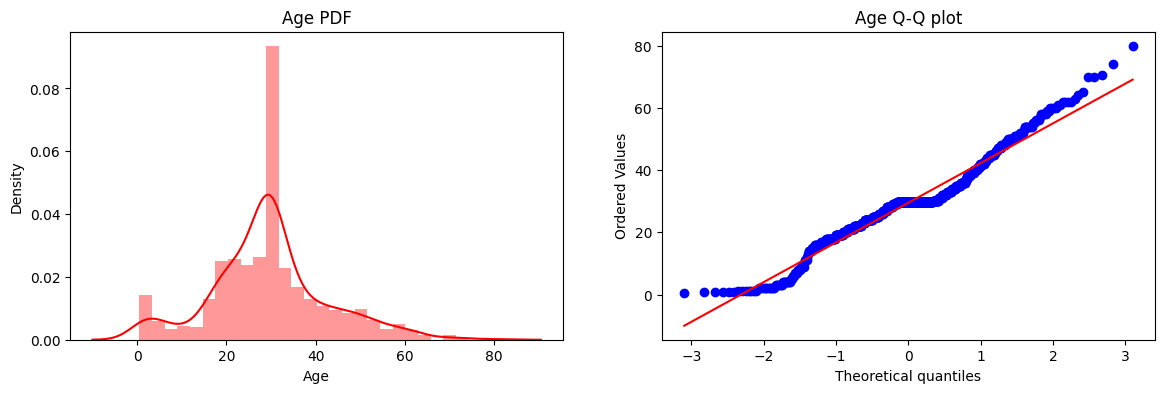

In [15]:
from scipy.stats import probplot

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'],color='r')
plt.title('Age PDF')

plt.subplot(122)
probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age Q-Q plot')

plt.show()

C:\Users\chara\AppData\Local\Temp\ipykernel_15952\3362061951.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'],color='r')


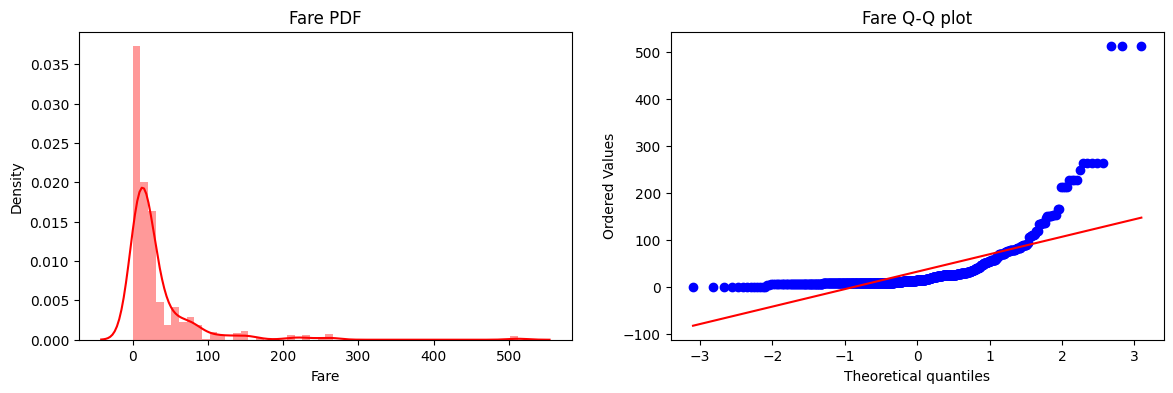

In [16]:
from scipy.stats import probplot

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'],color='r')
plt.title('Fare PDF')


plt.subplot(122)
probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare Q-Q plot')

plt.show()

In [18]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

ypredd = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

print('Logistic Regression Accuracy:',accuracy_score(y_test,ypredd))
print('Decision Tree Accuracy:',accuracy_score(y_test,y_pred2))

Logistic Regression Accuracy: 0.6480446927374302
Decision Tree Accuracy: 0.664804469273743


In [19]:
trf = FunctionTransformer(func=np.log1p)


In [20]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.fit_transform(X_test)



In [21]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)


y_pred_t = clf.predict(X_test_transformed)
y_pred2_t = clf2.predict(X_test_transformed)


print('Logistic Regression Accuracy:',accuracy_score(y_test,y_pred_t))
print('Decision Tree Accuracy:',accuracy_score(y_test,y_pred2_t))

Logistic Regression Accuracy: 0.6815642458100558
Decision Tree Accuracy: 0.6871508379888268


C:\Users\chara\AppData\Local\Temp\ipykernel_15952\1097276332.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed['Fare'],color='r')


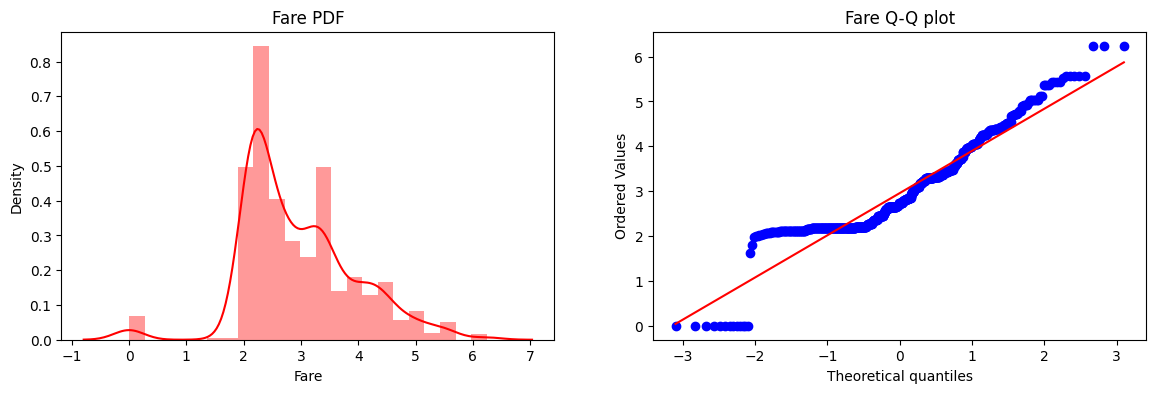

In [23]:
from scipy.stats import probplot

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train_transformed['Fare'],color='r')
plt.title('Fare PDF')

plt.subplot(122)
probplot(X_train_transformed['Fare'], dist='norm', plot=plt)
plt.title('Fare Q-Q plot')

plt.show()

In [24]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [25]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.659217877094972
